# Bar Chart Visualization

Bar charts for RMSE/MAE comparison with automatic color schemes.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Example data: learning rate comparison
labels = ['1e-2', '1e-3', '1e-4', '1e-5']
tasks = ['EAST-CHA', 'EAST-PAR', 'EAST-SST']

data_rmse = {
    'EAST-CHA': [0.0338, 0.0165, 0.0225, 0.0322],
    'EAST-PAR': [9.5478, 5.5888, 7.2722, 9.4257],
    'EAST-SST': [1.9606, 0.5731, 0.9439, 1.8648]
}

data_mae = {
    'EAST-CHA': [0.0245, 0.0106, 0.0149, 0.0239],
    'EAST-PAR': [7.0894, 3.7396, 5.1458, 7.0834],
    'EAST-SST': [1.5515, 0.4474, 0.7304, 1.4880]
}

## RMSE/MAE Comparison Chart


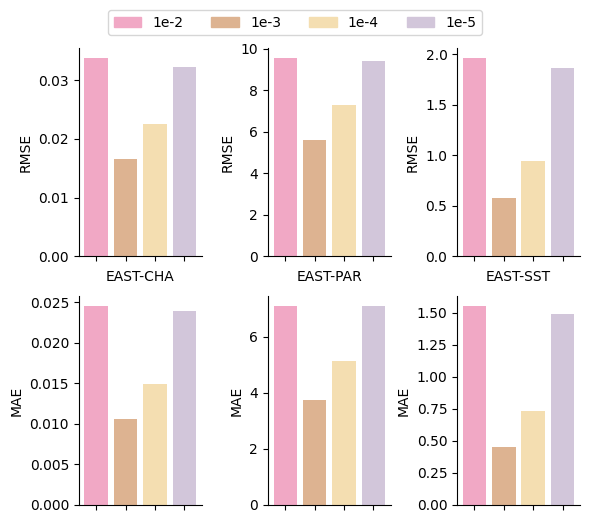

In [2]:
def plot_rmse_mae_bar(labels, tasks, data_rmse, data_mae):
    """Plot RMSE/MAE comparison bar chart"""
    # Auto color selection
    if len(labels) == 4:
        colors = ['#F1A8C5', '#DDB391', '#F4DEB1', '#D2C6DA']
    elif len(labels) == 5:
        colors = ['#999999', '#F7D7B0', '#E4E7A2', '#99DAEE', '#CFB4C2']
    else:
        colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    
    fig, axes = plt.subplots(2, len(tasks), figsize=(6, 5), sharey=False)
    
    if len(tasks) == 1:
        axes = axes.reshape(2, 1)
    
    for i, task in enumerate(tasks):
        ax_rmse = axes[0, i]
        ax_mae = axes[1, i]
        
        ax_rmse.bar(labels, data_rmse[task], color=colors)
        ax_rmse.set_ylabel('RMSE')
        ax_rmse.spines['top'].set_visible(False)
        ax_rmse.spines['right'].set_visible(False)
        ax_rmse.set_xticklabels([])
        ax_rmse.text(0.5, -0.1, task, ha='center', va='center', transform=ax_rmse.transAxes)
        
        ax_mae.bar(labels, data_mae[task], color=colors)
        ax_mae.set_ylabel('MAE')
        ax_mae.spines['top'].set_visible(False)
        ax_mae.spines['right'].set_visible(False)
        ax_mae.set_xticklabels([])
        
    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
    fig.legend(handles=handles, loc='upper center', ncol=len(labels), 
               bbox_to_anchor=(0.5, 1.05))
    
    plt.tight_layout()
    return fig

fig = plot_rmse_mae_bar(labels, tasks, data_rmse, data_mae)
plt.show()

## Dimension Comparison


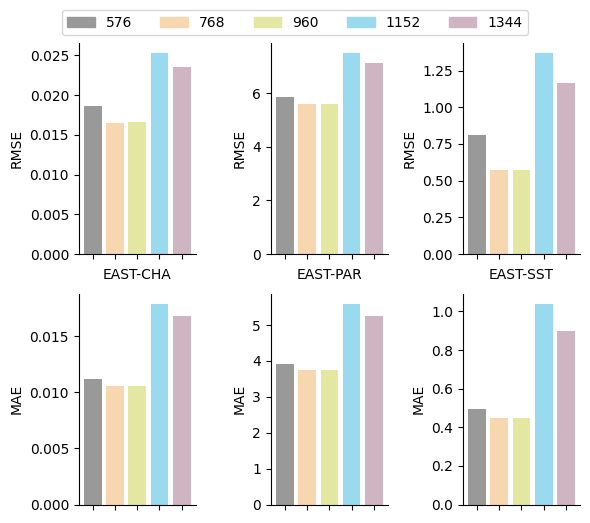

In [3]:
# Dimension comparison data
dim_labels = ['576', '768', '960', '1152', '1344']

dim_rmse = {
    'EAST-CHA': [0.0186, 0.0165, 0.0166, 0.0253, 0.0236],
    'EAST-PAR': [5.8414, 5.5888, 5.5787, 7.4908, 7.1026],
    'EAST-SST': [0.8084, 0.5731, 0.5736, 1.3692, 1.1681]
}

dim_mae = {
    'EAST-CHA': [0.0112, 0.0106, 0.0106, 0.0179, 0.0168],
    'EAST-PAR': [3.9093, 3.7396, 3.7463, 5.5966, 5.2362],
    'EAST-SST': [0.4950, 0.4474, 0.4501, 1.0405, 0.8982]
}

fig = plot_rmse_mae_bar(dim_labels, tasks, dim_rmse, dim_mae)
plt.show()